# 1. Data Acquisition & Reconstruction

## Objective

Load telemetry from PostgreSQL and reconstruct the original wide-format hardware snapshots from the EAV schema.

## Questions

1. How is telemetry stored?
2. How many readings exist?
3. Can the original hardware packets be reconstructed?

In [1]:
import os
from dotenv import load_dotenv
from sqlalchemy import create_engine
import pandas as pd

In [2]:
load_dotenv()

True

In [3]:
db_user = os.getenv("POSTGRES_USER")
db_password = os.getenv("POSTGRES_PASSWORD")
db_name = os.getenv("POSTGRES_DB")
db_host = os.getenv("POSTGRES_HOST")
db_port = os.getenv("POSTGRES_PORT")

if not db_password:
    raise ValueError(
        "CRITICAL: .env file was not found or POSTGRES_PASSWORD is completely empty!"
    )

In [4]:
database_url = f"postgresql://{db_user}:{db_password}@{db_host}:{db_port}/{db_name}"

In [5]:
engine = create_engine(database_url)

In [6]:
query = "SELECT * FROM sensor_readings ORDER BY timestamp ASC;"

In [7]:
df = pd.read_sql_query(query, con=engine)

In [8]:
print(f"Secure pipeline established! Loaded Matrix Shape: {df.shape}")
df.head()

Secure pipeline established! Loaded Matrix Shape: (3000, 5)


,id,line_id,sensor_type,value,timestamp
0,1,Line_1,torque,158.940855,2025-09-14 00:00:00+00:00
1,2,Line_1,conveyor_speed,1149.662733,2025-09-14 00:00:00+00:00
2,3,Line_1,fill_level,71.671263,2025-09-14 00:00:00+00:00
3,4,Line_1,torque,214.369669,2025-09-14 00:01:00+00:00
4,5,Line_1,conveyor_speed,845.887364,2025-09-14 00:01:00+00:00


In [9]:
# 1. Reconstitute the long EAV database rows into a wide mathematical matrix
df_matrix = df.pivot(
    index=["timestamp", "line_id"], columns="sensor_type", values="value"
).reset_index()

In [10]:
# Strip the categorical index name for a clean column layout
df_matrix.columns.name = None

In [11]:
print(f"Raw Database Records Extracted: {df.shape[0]} rows")
print(
    f"Reconstituted Snapshot Matrix:  {df_matrix.shape[0]} rows (1,000 chronological ticks)\n"
)

Raw Database Records Extracted: 3000 rows
Reconstituted Snapshot Matrix:  1000 rows (1,000 chronological ticks)



# 2. Dataset Overview

## Objective

Validate the generated dataset and anomaly distribution.

## Questions

1. How many records exist?
2. Are there missing values?
3. What percentage of observations are anomalies?

In [12]:
eda_df = pd.read_csv("../data/sensor_data.csv")

print(eda_df.shape)

eda_df.head()

(129600, 6)


,timestamp,line_id,torque,conveyor_speed,fill_level,is_anomaly
0,2025-09-14 00:00:00,Line_1,158.940855,1149.662733,71.671263,0.0
1,2025-09-14 00:01:00,Line_1,214.369669,845.887364,46.525836,1.0
2,2025-09-14 00:02:00,Line_1,198.430528,895.073273,61.271041,0.0
3,2025-09-14 00:03:00,Line_1,194.129144,1000.053529,83.180828,0.0
4,2025-09-14 00:04:00,Line_1,145.785239,1204.573615,70.245616,0.0


In [13]:
eda_df.shape
eda_df.isnull().sum()
eda_df["is_anomaly"].value_counts()
eda_df["is_anomaly"].value_counts(normalize=True)

is_anomaly
0.0    0.95
1.0    0.05
Name: proportion, dtype: float64

# 3. Baseline Sensor Statistics

## Objective

Characterize normal operating behavior for each sensor stream.

In [14]:
# Compute comprehensive statistical distributions simultaneously
df_summary = df_matrix[["conveyor_speed", "fill_level", "torque"]].describe()
# df_summary.head()
df_matrix.head()

,timestamp,line_id,conveyor_speed,fill_level,torque
0,2025-09-14 00:00:00+00:00,Line_1,1149.662733,71.671263,158.940855
1,2025-09-14 00:01:00+00:00,Line_1,845.887364,46.525836,214.369669
2,2025-09-14 00:02:00+00:00,Line_1,895.073273,61.271041,198.430528
3,2025-09-14 00:03:00+00:00,Line_1,1000.053529,83.180828,194.129144
4,2025-09-14 00:04:00+00:00,Line_1,1204.573615,70.245616,145.785239


In [15]:
df_summary.loc["iqr"] = df_summary.loc["75%"] - df_summary.loc["25%"]

In [16]:
# Display our baseline operational envelopes
df_summary.loc[["mean", "std", "iqr"]]

,conveyor_speed,fill_level,torque
mean,1163.935385,77.856662,157.732429
std,131.492808,11.190927,26.837675
iqr,119.284893,13.421610,28.514683


In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

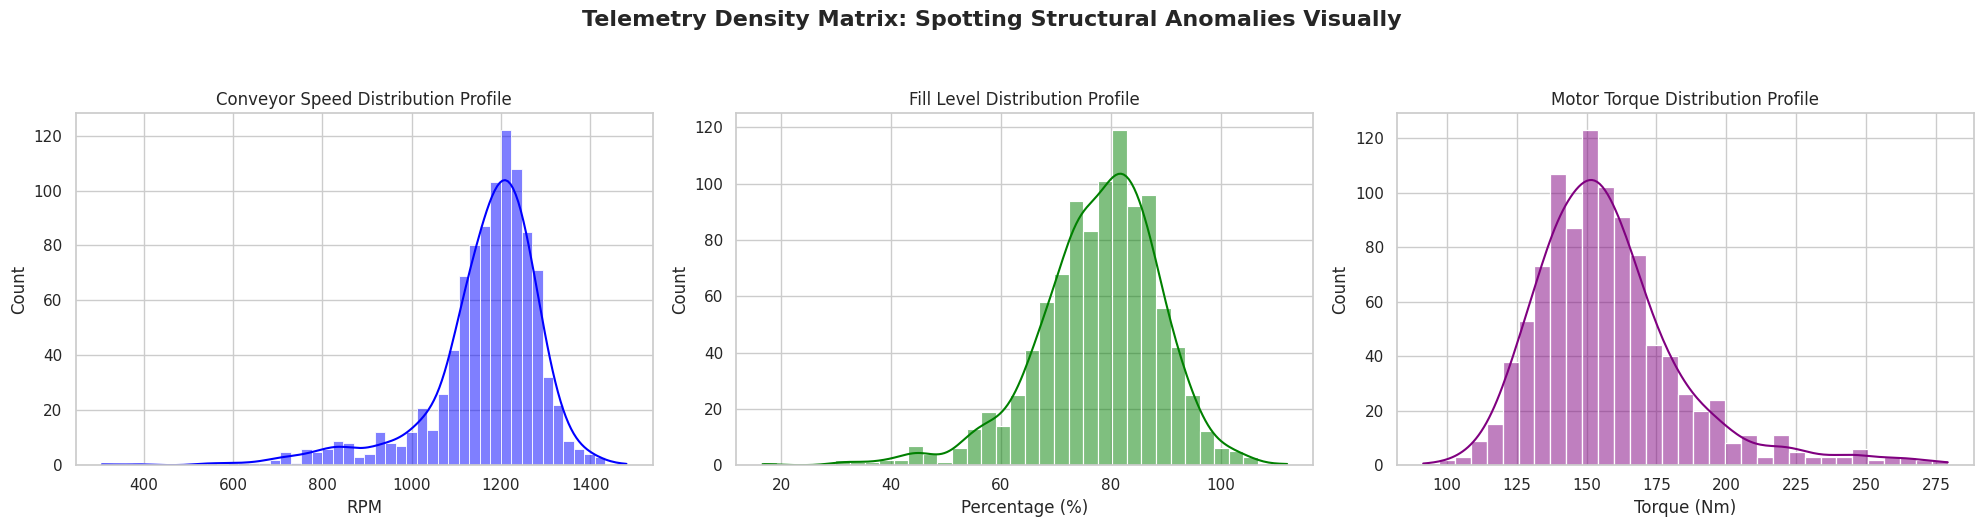

In [18]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Plot kernel density distributions for all three sensors
sns.histplot(data=df_matrix, x="conveyor_speed", kde=True, ax=axes[0], color="blue")
axes[0].set_title("Conveyor Speed Distribution Profile")
axes[0].set_xlabel("RPM")

sns.histplot(data=df_matrix, x="fill_level", kde=True, ax=axes[1], color="green")
axes[1].set_title("Fill Level Distribution Profile")
axes[1].set_xlabel("Percentage (%)")

sns.histplot(data=df_matrix, x="torque", kde=True, ax=axes[2], color="purple")
axes[2].set_title("Motor Torque Distribution Profile")
axes[2].set_xlabel("Torque (Nm)")

plt.suptitle(
    "Telemetry Density Matrix: Spotting Structural Anomalies Visually",
    fontsize=16,
    weight="bold",
    y=1.05,
)
plt.tight_layout()
plt.show()

# 4. Normal vs Anomaly Behavior

## Objective

Validate whether anomaly observations exhibit statistically different behavior from normal operating conditions.

## Questions

1. Do anomalies increase motor torque?
2. Do anomalies reduce conveyor speed?
3. Do anomalies reduce fill levels?
4. How much overlap exists between normal and anomalous operating states?
5. Is the dataset trivially separable or does meaningful class overlap exist?

The anomaly generator simulates a Mechanical Conveyor Jam:

- Torque increases due to motor strain.
- Conveyor speed decreases due to mechanical resistance.
- Fill level decreases due to bottle misalignment and spillage.

This section validates whether those behaviors are visible in the generated dataset.

In [19]:
anomaly_stats = eda_df.groupby("is_anomaly")[
    ["torque", "conveyor_speed", "fill_level"]
].agg(["mean", "median", "std"])

anomaly_stats

torque                        conveyor_speed               \
                  mean      median        std           mean       median   
is_anomaly                                                                  
0.0         152.625778  151.708819  20.316373    1187.188941  1192.816303   
1.0         217.463688  221.362418  36.908807     863.884321   824.786881   

                       fill_level                        
                   std       mean     median        std  
is_anomaly                                               
0.0          89.348849  79.158188  79.384615   9.655323  
1.0         197.873124  57.920058  55.497376  17.823613

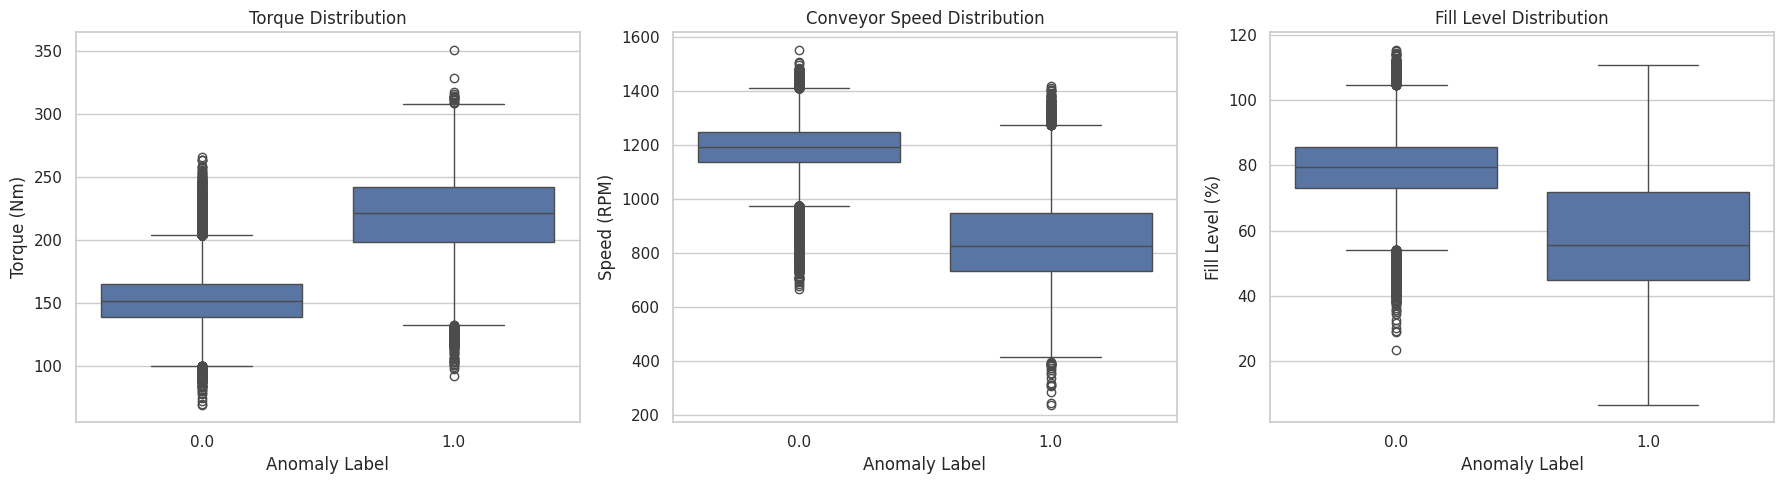

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(data=eda_df, x="is_anomaly", y="torque", ax=axes[0])

axes[0].set_title("Torque Distribution")
axes[0].set_xlabel("Anomaly Label")
axes[0].set_ylabel("Torque (Nm)")

sns.boxplot(data=eda_df, x="is_anomaly", y="conveyor_speed", ax=axes[1])

axes[1].set_title("Conveyor Speed Distribution")
axes[1].set_xlabel("Anomaly Label")
axes[1].set_ylabel("Speed (RPM)")

sns.boxplot(data=eda_df, x="is_anomaly", y="fill_level", ax=axes[2])

axes[2].set_title("Fill Level Distribution")
axes[2].set_xlabel("Anomaly Label")
axes[2].set_ylabel("Fill Level (%)")

plt.tight_layout()
plt.show()

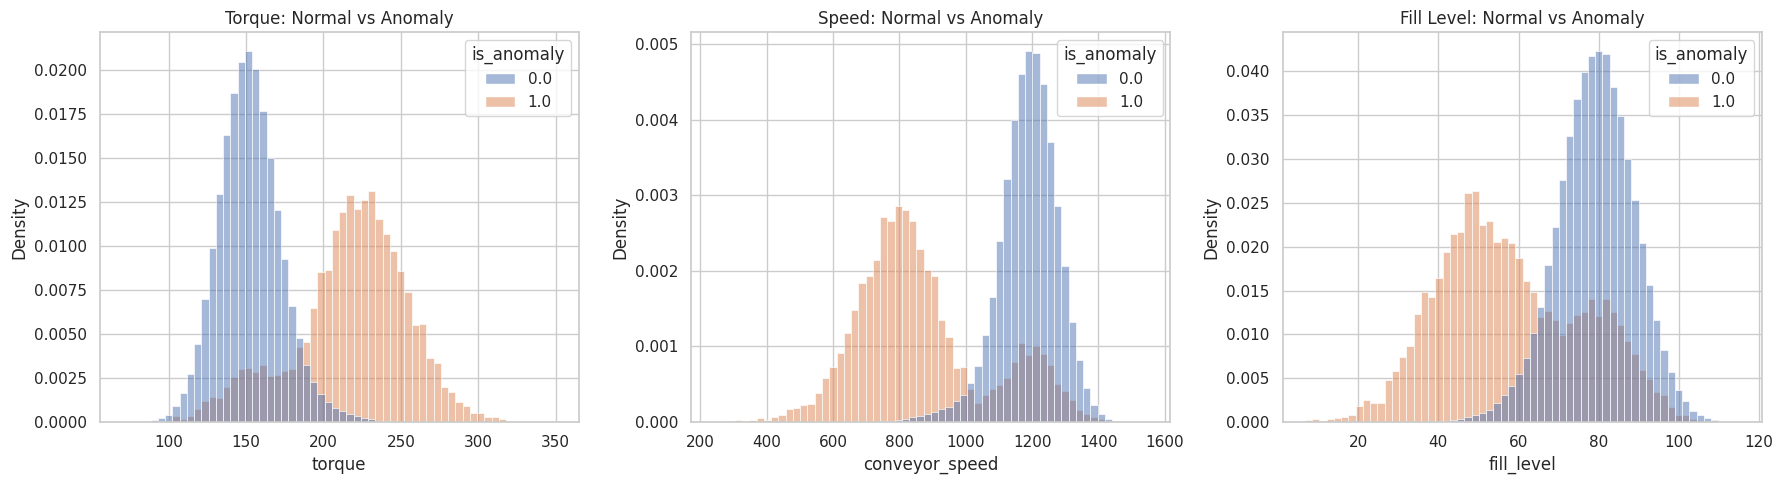

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(
    data=eda_df,
    x="torque",
    hue="is_anomaly",
    stat="density",
    common_norm=False,
    bins=60,
    ax=axes[0],
)

axes[0].set_title("Torque: Normal vs Anomaly")

sns.histplot(
    data=eda_df,
    x="conveyor_speed",
    hue="is_anomaly",
    stat="density",
    common_norm=False,
    bins=60,
    ax=axes[1],
)

axes[1].set_title("Speed: Normal vs Anomaly")

sns.histplot(
    data=eda_df,
    x="fill_level",
    hue="is_anomaly",
    stat="density",
    common_norm=False,
    bins=60,
    ax=axes[2],
)

axes[2].set_title("Fill Level: Normal vs Anomaly")

plt.tight_layout()
plt.show()

## Findings

- Anomaly events exhibit elevated torque values relative to normal operations.
- Anomaly events exhibit reduced conveyor speeds.
- Anomaly events exhibit reduced fill levels.
- Significant distribution overlap exists between classes.
- Increased baseline noise successfully prevents perfect class separation.

## Impact on Modeling

The dataset is not trivially separable using simple threshold rules.

Future models should leverage:

- Rolling statistics
- Multi-sensor relationships
- Temporal context

rather than relying solely on raw sensor values.

# 5. Correlation Analysis

## Objective

Investigate relationships between sensors and validate whether failures generate correlated disturbances.

## Questions

1. Do torque and speed move in opposite directions?
2. Do torque and fill level move in opposite directions?
3. Do failures affect multiple sensors simultaneously?
4. Are cross-sensor features likely to be useful during model training?

In [22]:
corr_matrix = eda_df[["torque", "conveyor_speed", "fill_level"]].corr()

corr_matrix

,torque,conveyor_speed,fill_level
torque,1.000000,-0.432831,-0.308226
conveyor_speed,-0.432831,1.000000,0.332340
fill_level,-0.308226,0.332340,1.000000


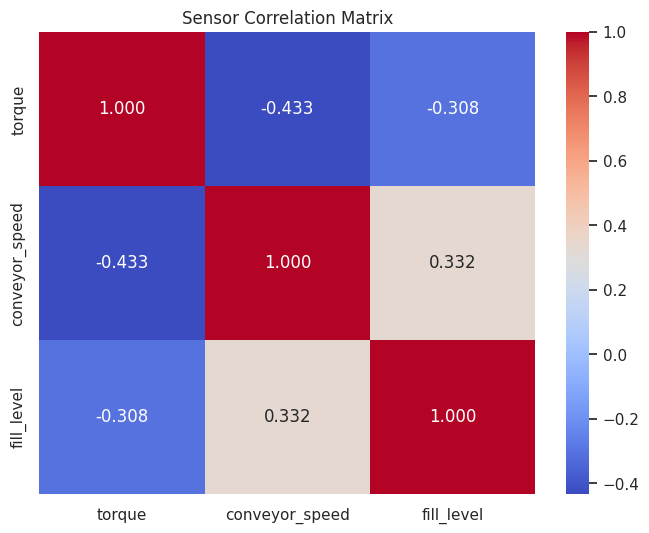

In [23]:
plt.figure(figsize=(8, 6))

sns.heatmap(corr_matrix, annot=True, fmt=".3f", cmap="coolwarm")

plt.title("Sensor Correlation Matrix")
plt.show()

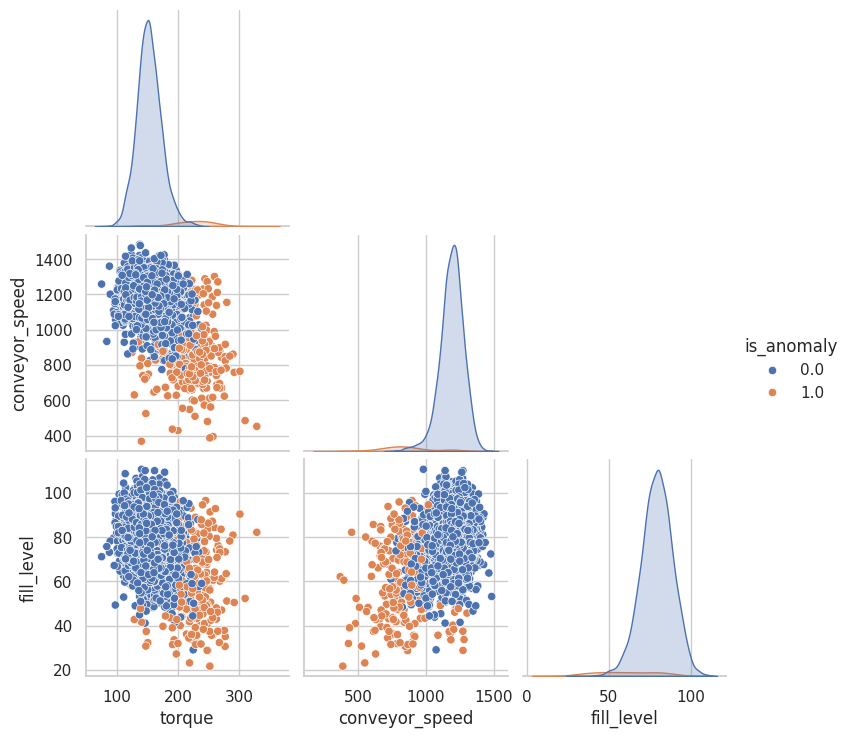

In [24]:
sample_df = eda_df.sample(n=5000, random_state=42)

sns.pairplot(
    sample_df,
    vars=["torque", "conveyor_speed", "fill_level"],
    hue="is_anomaly",
    corner=True,
)

plt.show()

## Findings

- Torque exhibits negative correlation with conveyor speed.
- Torque exhibits negative correlation with fill level.
- Speed and fill level exhibit positive correlation.
- Sensor relationships align with the Mechanical Conveyor Jam hypothesis.

## Impact on Modeling

The anomaly detection task is not purely univariate.

Cross-sensor relationships may provide predictive information beyond individual sensor readings.

Potential candidate features:

- Torque / Conveyor Speed
- Torque × Fill Level
- Rolling Cross-Sensor Correlations

# 6. Temporal Behavior Analysis

## Objective

Understand how sensor values evolve through time and evaluate candidate temporal features.

In [25]:
print("=== COMPUTING CHRONOLOGICAL ROLLING FEATURES ===")
# Create a copy of our wide matrix and ensure it is sorted perfectly by time
df_features = df_matrix.sort_values(by="timestamp").copy()

# Compute 30-minute (30 rows) rolling statistics for each sensor stream
# We use min_periods=1 so that the code doesn't return empty values at the very start
df_features["speed_roll_mean"] = (
    df_features["conveyor_speed"].rolling(window=30, min_periods=1).mean()
)
df_features["speed_roll_std"] = (
    df_features["conveyor_speed"].rolling(window=30, min_periods=1).std().fillna(0)
)

# Calculate the dynamic, time-aware Rolling Z-Score for conveyor speed
# We add a tiny epsilon (1e-6) to prevent a ZeroDivisionError if std ever hits exactly 0
df_features["speed_z_score"] = (
    df_features["conveyor_speed"] - df_features["speed_roll_mean"]
) / (df_features["speed_roll_std"] + 1e-6)

print("Feature transformation complete! Dynamic Z-scores generated.")
df_features[
    [
        "timestamp",
        "conveyor_speed",
        "speed_roll_mean",
        "speed_roll_std",
        "speed_z_score",
    ]
].head(10)

=== COMPUTING CHRONOLOGICAL ROLLING FEATURES ===
Feature transformation complete! Dynamic Z-scores generated.


,timestamp,conveyor_speed,speed_roll_mean,speed_roll_std,speed_z_score
0,2025-09-14 00:00:00+00:00,1149.662733,1149.662733,0.000000,0.000000
1,2025-09-14 00:01:00+00:00,845.887364,997.775049,214.801623,-0.707107
2,2025-09-14 00:02:00+00:00,895.073273,963.541124,163.051383,-0.419916
3,2025-09-14 00:03:00+00:00,1000.053529,972.669225,134.376801,0.203787
4,2025-09-14 00:04:00+00:00,1204.573615,1019.050103,155.880636,1.190164
5,2025-09-14 00:05:00+00:00,1156.655867,1041.984397,150.316031,0.762869
6,2025-09-14 00:06:00+00:00,1212.674085,1066.368638,151.628591,0.964894
7,2025-09-14 00:07:00+00:00,1166.758223,1078.917336,144.798228,0.606643
8,2025-09-14 00:08:00+00:00,1122.468159,1083.756317,136.222070,0.284182
9,2025-09-14 00:09:00+00:00,1239.587113,1099.339396,137.560707,1.019533


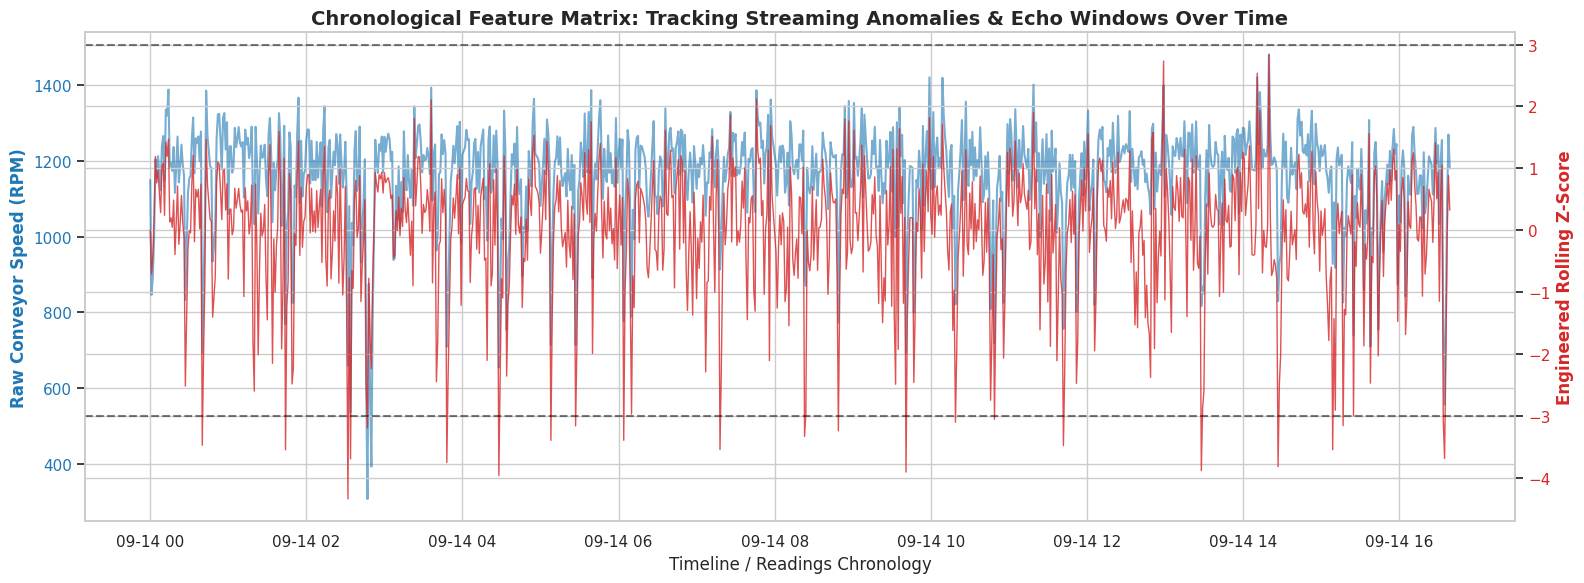

In [26]:
# Set up a dual-axis plotting layout
fig, ax1 = plt.subplots(figsize=(16, 6))

# 1. Plot the Raw Conveyor Speed timeline on the left axis
color = "tab:blue"
ax1.set_xlabel("Timeline / Readings Chronology")
ax1.set_ylabel("Raw Conveyor Speed (RPM)", color=color, weight="bold")
ax1.plot(
    df_features["timestamp"],
    df_features["conveyor_speed"],
    color=color,
    alpha=0.6,
    label="Raw Speed",
)
ax1.tick_params(axis="y", labelcolor=color)

# 2. Instantiate a second axis sharing the exact same x-axis timeline
ax2 = ax1.twinx()

# Plot our engineered Rolling Z-Score on the right axis
color = "tab:red"
ax2.set_ylabel("Engineered Rolling Z-Score", color=color, weight="bold")
ax2.plot(
    df_features["timestamp"],
    df_features["speed_z_score"],
    color=color,
    alpha=0.8,
    linewidth=1,
    label="Z-Score",
)
ax2.tick_params(axis="y", labelcolor=color)

# Draw our industrial standard statistical anomaly thresholds (+/- 3 standard deviations)
ax2.axhline(
    y=3.0, color="black", linestyle="--", alpha=0.5, label="Threshold Boundary (+3σ)"
)
ax2.axhline(y=-3.0, color="black", linestyle="--", alpha=0.5)

plt.title(
    "Chronological Feature Matrix: Tracking Streaming Anomalies & Echo Windows Over Time",
    fontsize=14,
    weight="bold",
)
fig.tight_layout()
plt.show()

# 7. Temporal Bleed Validation

## Objective

Validate whether anomaly effects persist beyond the labelled anomaly event.

The generator intentionally applies residual disturbance to the next two observations after each anomaly event.

This mechanism is designed to simulate recovery behavior commonly observed in industrial systems following a mechanical fault.

## Questions

1. Does the disturbance persist beyond the anomaly timestamp?
2. Is recovery gradual rather than instantaneous?
3. Will bleed rows create difficult classification boundaries?

In [27]:
anomaly_indices = eda_df.index[eda_df["is_anomaly"] == 1].tolist()

anomaly_indices[:10]

[1, 27, 40, 48, 65, 104, 109, 141, 152, 154]

In [31]:
import numpy as np

sample_indices = np.random.choice(anomaly_indices, size=3, replace=False)

sample_indices

array([ 40353,  31228, 112369])

In [32]:
for idx in sample_indices:
    window = eda_df.iloc[max(0, idx - 10) : idx + 10]

    print(f"\nAnomaly Index: {idx}")
    display(window)


Anomaly Index: 40353


,timestamp,line_id,torque,conveyor_speed,fill_level,is_anomaly
40343,2025-10-12 00:23:00,Line_1,145.877930,1190.092283,68.821567,0.0
40344,2025-10-12 00:24:00,Line_1,143.549619,1235.214224,91.068013,0.0
40345,2025-10-12 00:25:00,Line_1,162.957519,1130.768474,86.893872,0.0
40346,2025-10-12 00:26:00,Line_1,163.712176,1249.499482,66.773435,0.0
40347,2025-10-12 00:27:00,Line_1,133.973007,1072.211676,82.028984,0.0
40348,2025-10-12 00:28:00,Line_1,138.709356,1270.535880,77.268467,0.0
40349,2025-10-12 00:29:00,Line_1,136.934185,1266.090346,72.112965,0.0
40350,2025-10-12 00:30:00,Line_1,153.300337,1129.156033,79.284976,0.0
40351,2025-10-12 00:31:00,Line_1,166.320507,1307.726927,75.818872,0.0
40352,2025-10-12 00:32:00,Line_1,153.539976,1153.269994,91.501985,0.0



Anomaly Index: 31228


,timestamp,line_id,torque,conveyor_speed,fill_level,is_anomaly
31218,2025-10-05 16:18:00,Line_1,131.435469,1159.883890,85.844892,0.0
31219,2025-10-05 16:19:00,Line_1,170.553543,1179.043819,83.957889,0.0
31220,2025-10-05 16:20:00,Line_1,162.345754,1081.897551,75.788264,0.0
31221,2025-10-05 16:21:00,Line_1,149.876930,1254.365974,67.162185,0.0
31222,2025-10-05 16:22:00,Line_1,136.718608,1050.978416,94.261923,0.0
31223,2025-10-05 16:23:00,Line_1,139.534980,1120.800481,81.235472,0.0
31224,2025-10-05 16:24:00,Line_1,182.812607,1164.071782,75.007494,0.0
31225,2025-10-05 16:25:00,Line_1,153.211953,973.921637,93.432666,0.0
31226,2025-10-05 16:26:00,Line_1,173.937630,1088.065756,82.964443,0.0
31227,2025-10-05 16:27:00,Line_1,154.348044,1281.984273,81.974430,0.0



Anomaly Index: 112369


,timestamp,line_id,torque,conveyor_speed,fill_level,is_anomaly
112359,2025-12-01 00:39:00,Line_1,187.747282,1310.164747,87.846269,0.0
112360,2025-12-01 00:40:00,Line_1,190.441298,1294.641044,74.553980,0.0
112361,2025-12-01 00:41:00,Line_1,117.796387,1262.133745,82.045354,0.0
112362,2025-12-01 00:42:00,Line_1,141.472265,1014.821037,80.747218,0.0
112363,2025-12-01 00:43:00,Line_1,180.981236,1243.610814,83.722282,0.0
112364,2025-12-01 00:44:00,Line_1,168.222703,1181.799824,63.675512,0.0
112365,2025-12-01 00:45:00,Line_1,145.199557,1225.138201,95.349637,0.0
112366,2025-12-01 00:46:00,Line_1,171.860055,1133.212760,84.136764,0.0
112367,2025-12-01 00:47:00,Line_1,136.030348,1259.467888,97.280620,0.0
112368,2025-12-01 00:48:00,Line_1,137.286606,1211.215218,73.665669,0.0


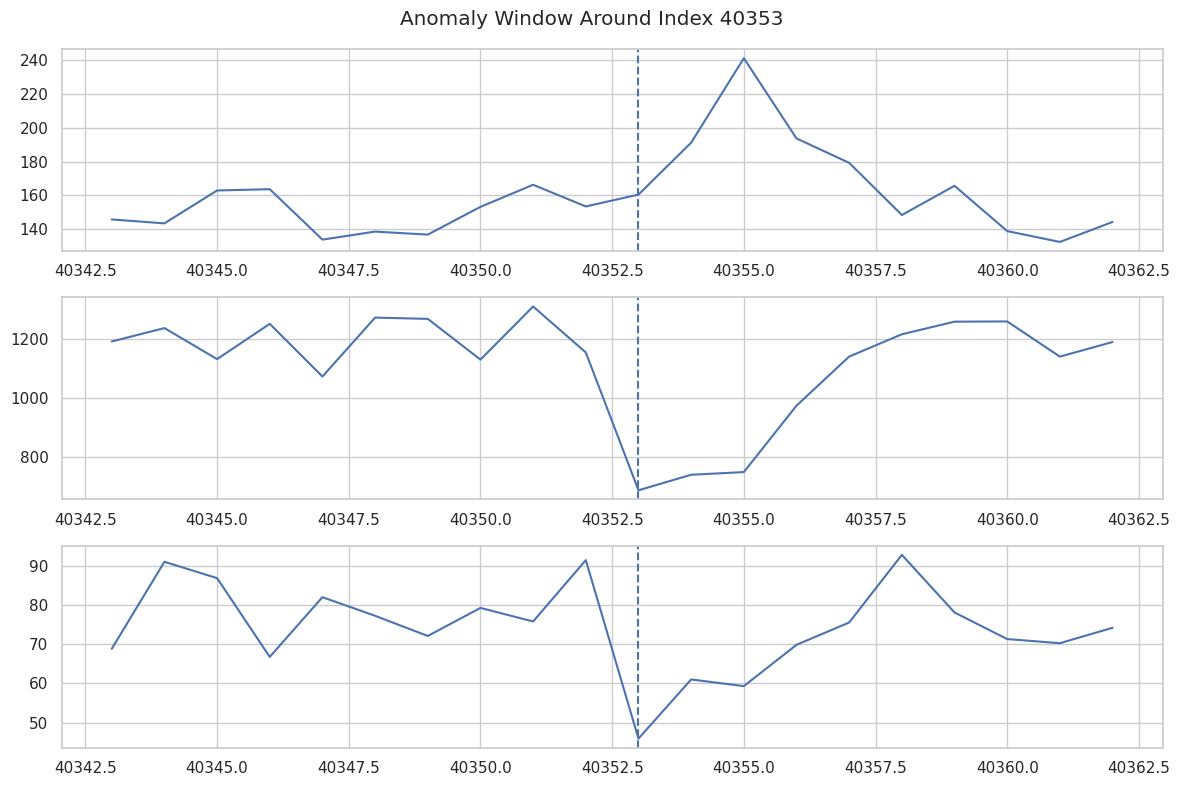

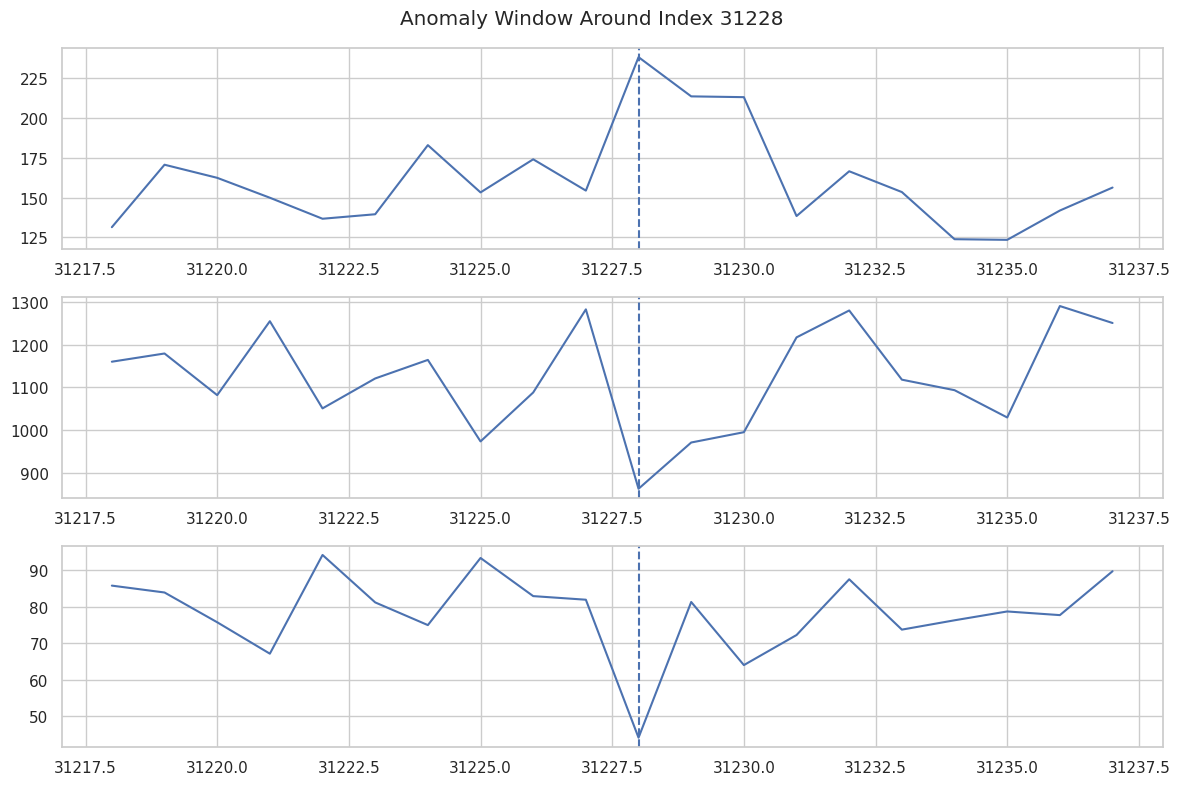

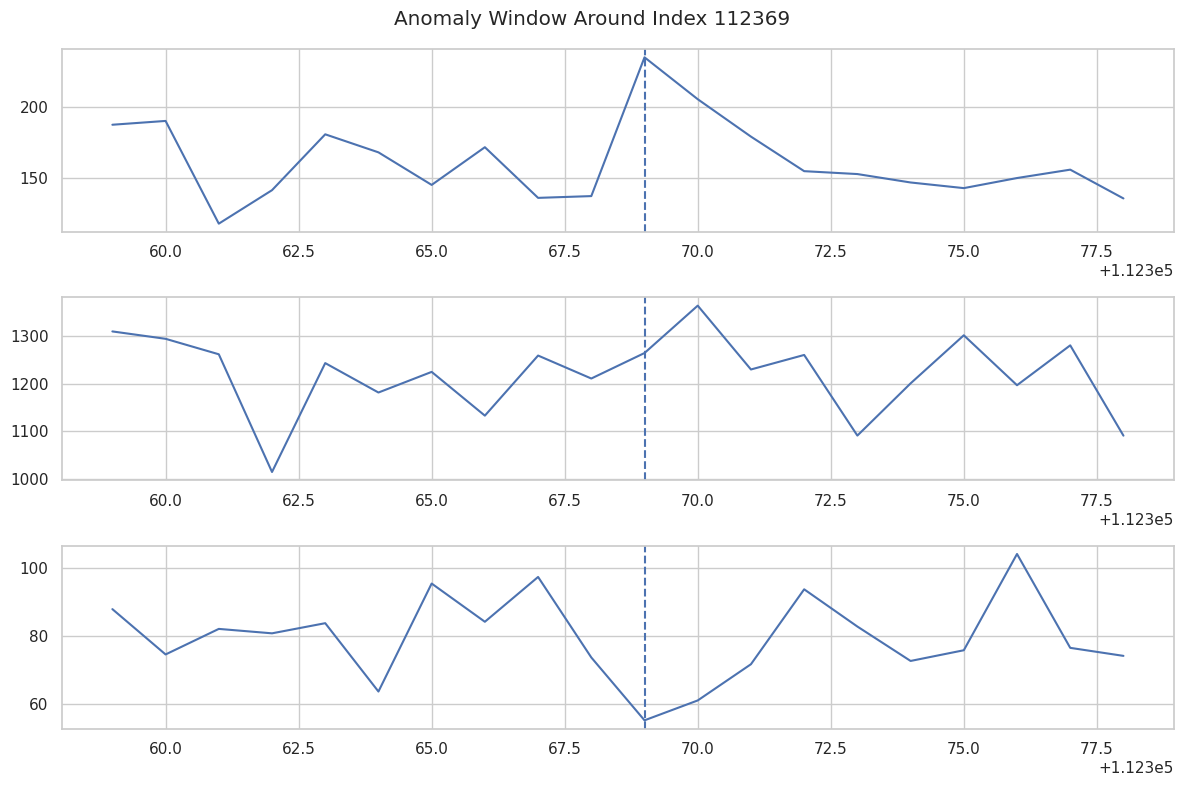

In [33]:
for idx in sample_indices:
    window = eda_df.iloc[max(0, idx - 10) : idx + 10]

    fig, axes = plt.subplots(3, 1, figsize=(12, 8))

    axes[0].plot(window.index, window["torque"])
    axes[0].axvline(idx, linestyle="--")

    axes[1].plot(window.index, window["conveyor_speed"])
    axes[1].axvline(idx, linestyle="--")

    axes[2].plot(window.index, window["fill_level"])
    axes[2].axvline(idx, linestyle="--")

    plt.suptitle(f"Anomaly Window Around Index {idx}")
    plt.tight_layout()
    plt.show()

## Findings

The disturbance does not immediately disappear after the labelled anomaly event.

Sensor values exhibit short-term recovery behavior over subsequent observations.

This confirms that the generator successfully introduces temporal dependence into the dataset.

## Impact on Modeling

Individual observations may not contain sufficient context.

Temporal features such as rolling statistics and rate-of-change metrics are likely to be more informative than raw values alone.

# 8. Class Boundary Difficulty

## Objective

Evaluate how difficult it is to distinguish anomalies from normal operating conditions.

The updated generator intentionally increases baseline sensor variance to create overlap between classes.

## Questions

1. Are anomalies trivially separable?
2. Do normal and anomaly distributions overlap?
3. Will simple threshold rules be sufficient?

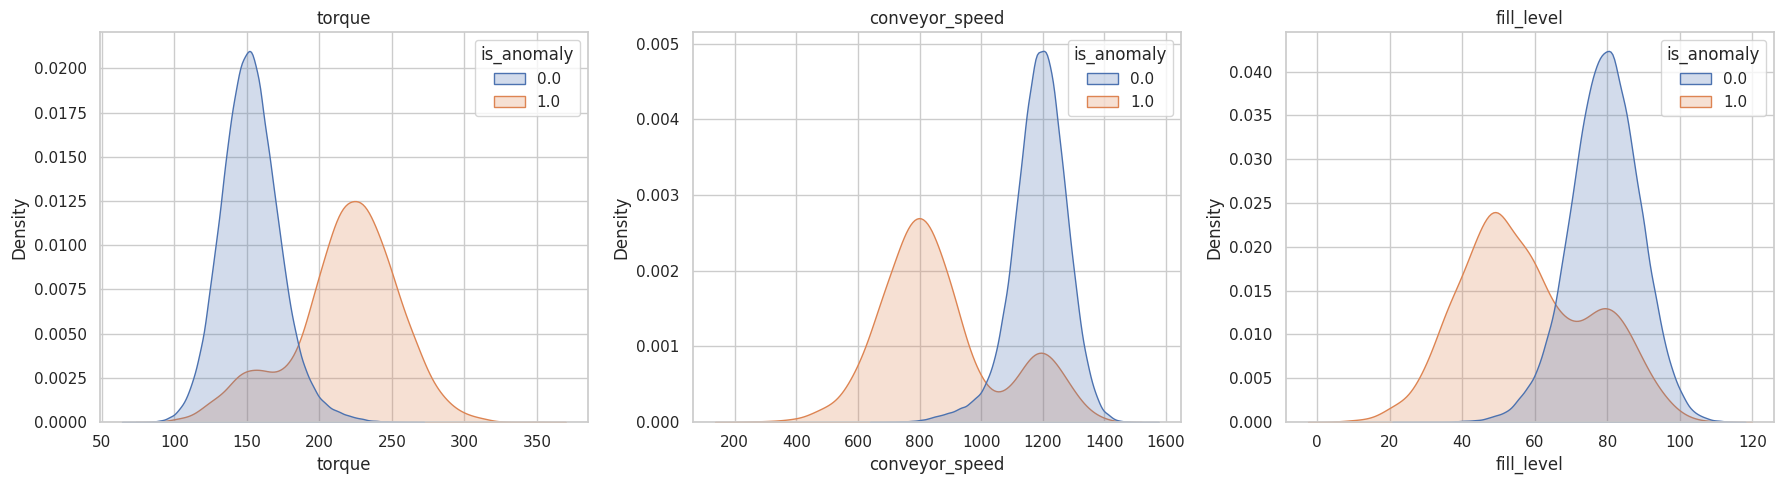

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col in zip(axes, ["torque", "conveyor_speed", "fill_level"]):
    sns.kdeplot(
        data=eda_df, x=col, hue="is_anomaly", fill=True, common_norm=False, ax=ax
    )

    ax.set_title(col)

plt.tight_layout()
plt.show()

## Findings

Anomaly and normal distributions exhibit visible overlap.

The dataset is no longer perfectly separable using simple threshold rules.

Low-magnitude anomalies fall closer to normal operating ranges, increasing classification difficulty.

## Impact on Modeling

Machine learning models will need to combine information from multiple sensors and temporal features rather than relying on single-variable thresholds.

# 9. Feature Engineering Insights

## Objective

Identify candidate predictive features based on observations from the exploratory analysis.

## Questions

1. What information is missing from raw sensor values?
2. Which transformations may improve predictive power?
3. Which EDA findings suggest temporal or cross-sensor features?

In [ ]:
candidate_features = [col for col in df_features.columns if "roll" in col.lower()]

df_features[
    ["timestamp", "torque", "conveyor_speed", "fill_level", *candidate_features]
].head()

,timestamp,torque,conveyor_speed,fill_level,speed_roll_mean,speed_roll_std
0,2025-09-14 00:00:00+00:00,158.940855,1149.662733,71.671263,1149.662733,0.000000
1,2025-09-14 00:01:00+00:00,214.369669,845.887364,46.525836,997.775049,214.801623
2,2025-09-14 00:02:00+00:00,198.430528,895.073273,61.271041,963.541124,163.051383
3,2025-09-14 00:03:00+00:00,194.129144,1000.053529,83.180828,972.669225,134.376801
4,2025-09-14 00:04:00+00:00,145.785239,1204.573615,70.245616,1019.050103,155.880636


## Feature Engineering Observations

### Temporal Features

The rolling statistics smooth short-term sensor noise while preserving longer-term operational trends.

### Why Rolling Features Matter

The temporal bleed analysis demonstrated that anomaly effects persist beyond the labelled event.

A single observation may therefore be insufficient to determine whether a system is operating normally.

Rolling statistics provide short-term historical context and may improve anomaly detection performance.

### Candidate Features for Model Training

- Rolling Mean (30-minute)
- Rolling Standard Deviation (30-minute)
- Z-Score
- Rate of Change
- Torque / Conveyor Speed
- Torque × Fill Level

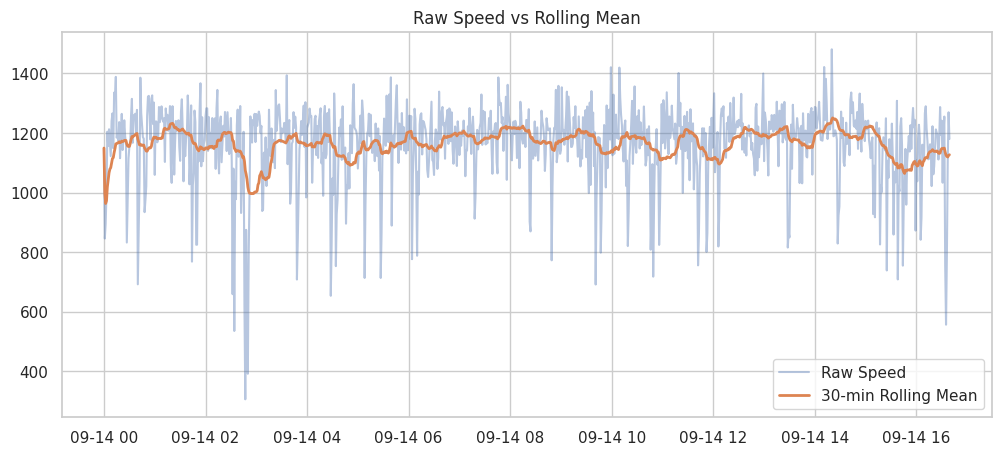

In [ ]:
plt.figure(figsize=(12, 5))

plt.plot(
    df_features["timestamp"],
    df_features["conveyor_speed"],
    alpha=0.4,
    label="Raw Speed",
)

plt.plot(
    df_features["timestamp"],
    df_features["speed_roll_mean"],
    linewidth=2,
    label="30-min Rolling Mean",
)

plt.legend()
plt.title("Raw Speed vs Rolling Mean")
plt.show()

# 10. Conclusions

## Objective

Summarize the major findings from the exploratory analysis and identify implications for feature engineering and model development.

---

## Dataset Validation

The generated dataset successfully matches the assumptions defined in ARCH-02 and ARCH-04.

Key observations include:

- Approximately 5% of observations are labelled as anomalies.
- No missing values were detected.
- Sensor baselines closely match the configured generation parameters.
- Increased baseline variance creates realistic overlap between normal and anomalous observations.

---

## Mechanical Conveyor Jam Validation

The anomaly injection process successfully produces the intended physical failure signature.

Observed anomaly characteristics include:

- Elevated motor torque caused by increased mechanical resistance.
- Reduced conveyor speed caused by friction and system slowdown.
- Reduced fill levels caused by container misalignment and spillage.

These behaviors are consistent with the intended Mechanical Conveyor Jam model.

---

## Cross-Sensor Relationships

Correlation analysis indicates that failures affect multiple sensors simultaneously rather than producing isolated spikes.

Key findings:

- Torque exhibits negative correlation with conveyor speed.
- Torque exhibits negative correlation with fill level.
- Conveyor speed and fill level generally move together.

This suggests that multi-sensor feature engineering may outperform purely univariate approaches.

---

## Temporal Behavior

Temporal analysis confirms that anomaly effects persist beyond the labelled event.

Observed behavior includes:

- Residual disturbance following anomaly events.
- Gradual recovery patterns rather than immediate normalization.
- Short-term temporal dependence between consecutive observations.

These findings validate the Temporal Bleed mechanism introduced in the data generator.

---

## Implications for Model Development

Several observations directly influence the next phase of development.

### Raw Values May Be Insufficient

Class overlap indicates that simple threshold-based detection will likely struggle with low-severity failures.

### Temporal Context Appears Important

Because anomaly effects persist across multiple observations, rolling-window statistics are likely to provide useful predictive information.

### Cross-Sensor Features Are Promising

Correlated failure behavior suggests that sensor interaction features may improve model performance.

Potential candidate features include:

- Rolling Mean
- Rolling Standard Deviation
- Z-Score
- Rate of Change
- Torque / Conveyor Speed
- Torque × Fill Level

---

## Dataset Limitations

The current simulation intentionally excludes several real-world operational behaviors:

- Sensor flatlining and hardware lockups
- Long-term covariate drift
- Seasonal production changes
- Multiple independent failure modes
- Sensor calibration degradation

These limitations should be considered when interpreting model performance.

---

## Next Steps

The next phase focuses on transforming these observations into predictive features and evaluating candidate machine learning models.

Planned activities include:

1. Feature Engineering
2. Feature Selection
3. Model Training
4. Model Evaluation
5. Champion Model Selection
6. Deployment Preparation